In [17]:
import pandas as pd
import numpy as np
import psycopg
from dotenv import load_dotenv
import os
import time
import requests
import warnings
import sys
sys.path.append("..")
warnings.simplefilter(action='ignore')



<b>W tym notatniku głównie są przedstawione analizy, wykresy bez interakcji itd. Notatnik służył jako "brudnopis" w trakcie projektu</b>

## Analiza danych

In [2]:
4 * 6 * 17/ 60

6.8

In [3]:
load_dotenv()

True

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [4]:
import sys
sys.path.append("..")
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from data_processing.data_utils import *

In [5]:
df = get_data_from_db()

Polaczono!


In [6]:
df = prepare_data(df)

In [7]:
df_dict = make_df_dict(df)

In [8]:
model_dict = model_dict_from_pickle()

In [14]:
uah = df_dict['uah']

X = uah.iloc[:,1:]
y = uah.iloc[:,[0]]

X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)

model = ARIMA(y_train, X_train, order = (2,2,1)).fit()
y_pred = model.get_forecast(exog = X_test, steps = len(X_test)).predicted_mean

C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
tscv = TimeSeriesSplit(n_splits = 5)
y_test_, y_pred_ = 0, 0
for train_ix, test_ix in tscv.split(X_train):
    X_train_cv = X_train.iloc[train_ix]
    y_train_cv = y_train.iloc[train_ix]
    X_test_cv = X_train.iloc[test_ix]
    y_test_cv = y_train.iloc[test_ix]
    
    model = ARIMA(y_train_cv, X_train_cv, order = (2,2,1)).fit()
    y_pred_cv = model.get_forecast(exog = X_test_cv, steps = len(X_test_cv)).predicted_mean

    r2 = r2_score(y_test_cv, y_pred_cv)
    rmse = root_mean_squared_error(y_test_cv, y_pred_cv)

    y_test_ = y_test_cv
    y_pred_ = y_pred_cv
    break
    print(f"RMSE = {float(rmse)}; R2 = {float(r2)}")

C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='date'>

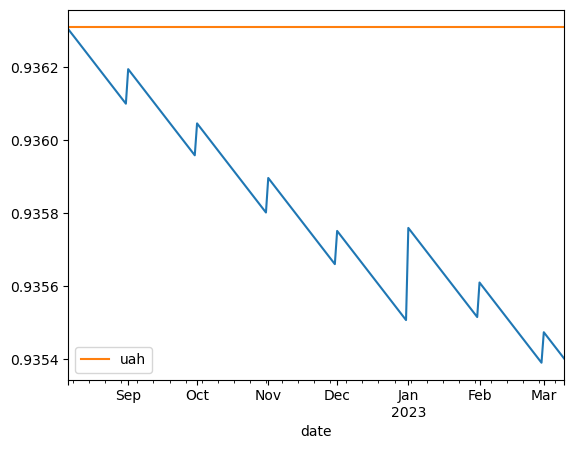

In [23]:
fig, ax = plt.subplots()

y_pred_.plot(ax = ax)
y_test_.plot(ax = ax)

<Axes: xlabel='date'>

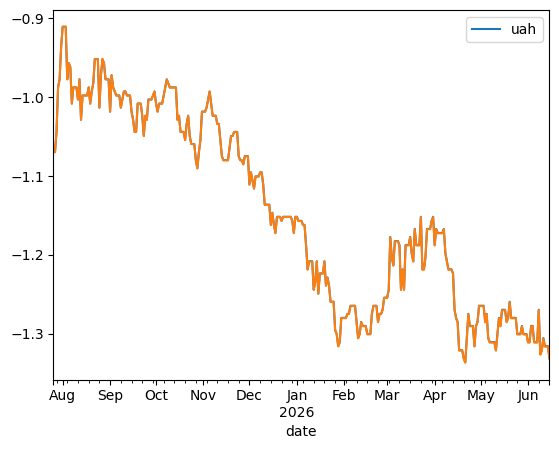

In [15]:
fig, axs = plt.subplots()

y_pred = pd.Series(y_pred, index = y_test.index)

y_test.plot(ax = axs)
y_pred.plot(ax = axs)

In [8]:
codes = ['usd', 'eur', 'huf', 'uah', 'jpy', 'czk']
codes_upp = []
for i in range(6):
    codes_upp.append(codes[i].upper())

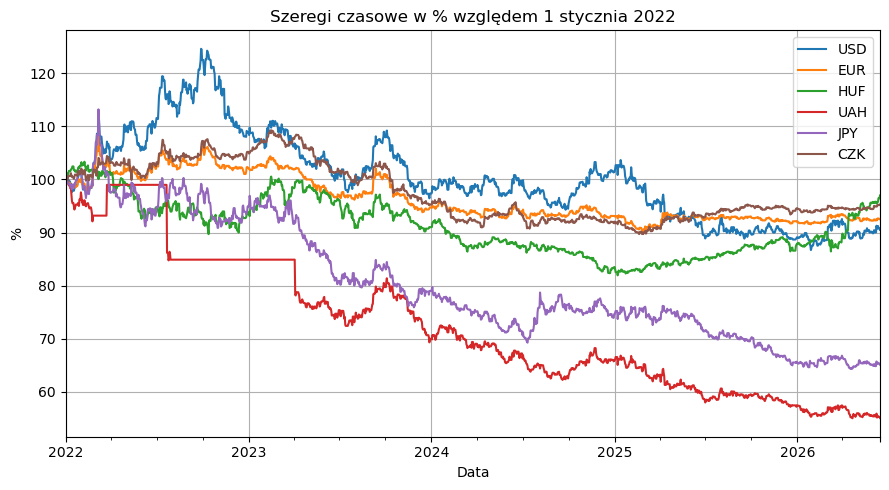

In [9]:
perc_df = (df / df.iloc[0] * 100)

fig, ax = plt.subplots(1, 1, figsize = (9,5), facecolor = 'white', tight_layout = True)

perc_df.plot(ax = ax).legend(labels = codes_upp)
plt.title("Szeregi czasowe w % względem 1 stycznia 2022")
plt.xlabel("Data")
plt.ylabel("%")
plt.grid(visible = True)

plt.show()

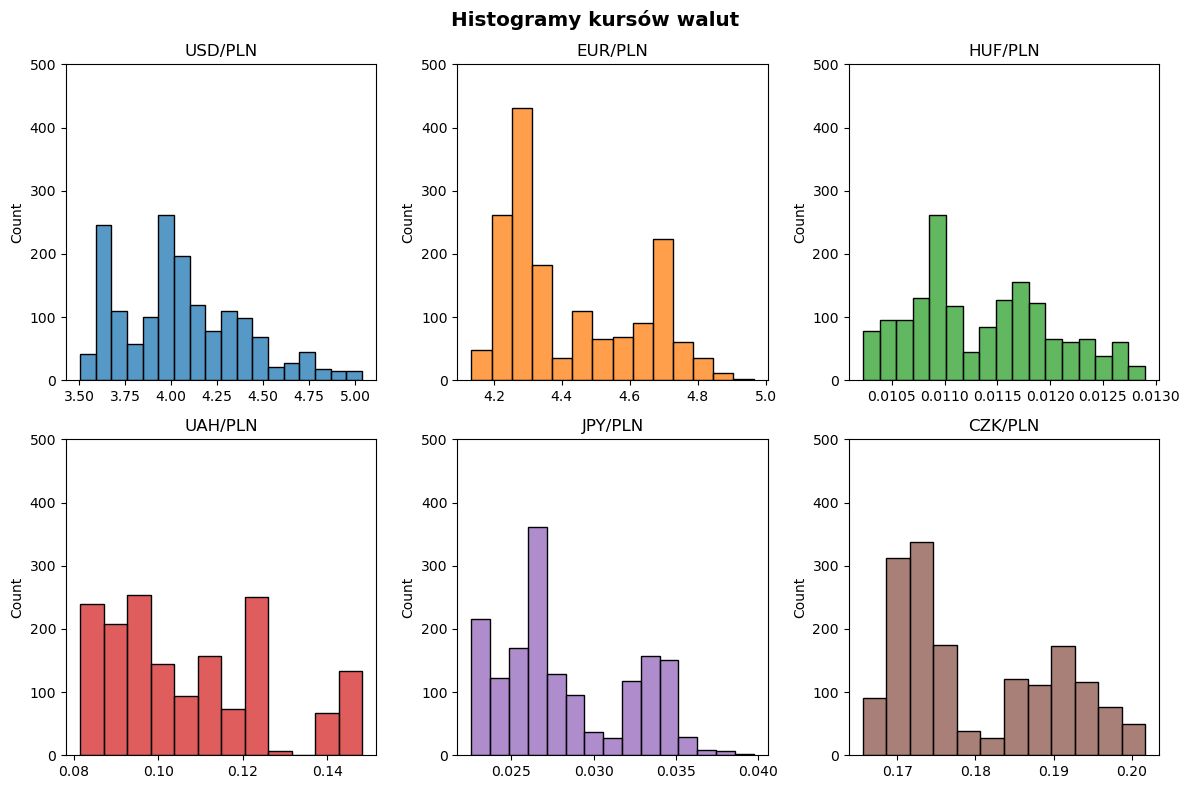

In [12]:
# histogramy

fig, axs = plt.subplots(2, 3, figsize = (12,8), facecolor = 'white', tight_layout = True)

colors = ['C0', "C1", "C2", 'C3', 'C4', 'C5']

fig.suptitle("Histogramy kursów walut", fontsize = "x-large", fontweight = "bold")

for ax, col, code, code_upp in zip(axs.flatten(), colors, codes, codes_upp):
    to_add = r"/PLN"
    sns.histplot(df[code], ax = ax, color = col)
    ax.set_xlabel(None)
    ax.set_title(code_upp + to_add)
    ax.set_ylim(0, 500)

In [13]:
sc = StandardScaler()
sc.fit_transform(df)

array([[-0.03092188,  0.84143455,  1.69667598,  2.08552249,  1.7192475 ,
         0.44673911],
       [-0.03092188,  0.84143455,  1.69667598,  2.08552249,  1.7192475 ,
         0.44673911],
       [-0.03092188,  0.84143455,  1.69667598,  2.08552249,  1.7192475 ,
         0.44673911],
       ...,
       [-1.15135147, -0.88977428,  1.02834134, -1.31593899, -1.34209283,
        -0.45111046],
       [-1.15135147, -0.88977428,  1.02834134, -1.31593899, -1.34209283,
        -0.45111046],
       [-1.1841196 , -0.90858624,  1.12533321, -1.33133022, -1.36120264,
        -0.43093406]], shape=(1627, 6))

In [116]:
def prepare_data(df):

    # standaryzacja danych
    sc = StandardScaler()
    data_scaled = sc.fit_transform(df)

    df_scaled = pd.DataFrame(data_scaled, index = df.index, columns = df.columns)

    # STL - dekompozycja szeregu czasowego
    for i, code in enumerate(codes_upp):
        ts = df_scaled.iloc[:,i]
        name = df_scaled.columns[i]
        stl_res = STL(ts, period = 24, seasonal = 15).fit()
    
        df_scaled[f"{code.lower()}_trend"] = stl_res.trend
        df_scaled[f"{code.lower()}_seasonal"] = stl_res.seasonal
        df_scaled[f"{code.lower()}_resid"] = stl_res.resid

    # przesunięcia
    for code in codes:
        for lag in [1,5,6,7]:
            df_scaled[f"{code}_lag{lag}"] = df_scaled[code].shift(lag)

    df_scaled = df_scaled.bfill()

    
    # okna czasowe - tygodniowe i miesięczne - średnia, mediana i odch. std rolling window
    for code in codes:

        # rolling window
        rolling_mean_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").mean().bfill()
        rolling_median_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").median().bfill()
        rolling_std_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").std().bfill()
    
        rolling_mean_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").mean().bfill()
        rolling_median_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").median().bfill()
        rolling_std_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").std().bfill()
    
        # expanding window
        expanding_mean = df_scaled[code].expanding().mean()
        expanding_median = df_scaled[code].expanding().median()
        expanding_std = df_scaled[code].expanding().std()
    
        # dodanie do df
        df_scaled[f"{code}_mean_week"] = rolling_mean_week
        df_scaled[f"{code}_median_week"] = rolling_median_week
        df_scaled[f"{code}_std_week"] = rolling_std_week
    
        df_scaled[f"{code}_mean_month"] = rolling_mean_month
        df_scaled[f"{code}_median_month"] = rolling_median_month
        df_scaled[f"{code}_std_month"] = rolling_std_month
    
        df_scaled[f"{code}_exp_mean"] = expanding_mean
        df_scaled[f"{code}_exp_median"] = expanding_median
        df_scaled[f"{code}_exp_std"] = expanding_std

    df_scaled = df_scaled.bfill()

    df_scaled['month'] = df.index.month.astype("category")
    df_scaled['day'] = df.index.day.astype("category")
    df_scaled['quarter'] = df.index.quarter.astype("category")
    df_scaled['weekday'] = df.index.dayofweek.astype("category")
    
    df_scaled = pd.get_dummies(df_scaled, columns = ['month', 'day', 'quarter', 'weekday'], drop_first = True)
    
    return df_scaled.astype(float)

In [104]:
temp = df.copy()
temp = prepare_data(df)
temp.iloc[:,-50:]

,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,...,day_31,quarter_2,quarter_3,quarter_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2022-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2022-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2026-06-12,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2026-06-13,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [99]:
temp = prepare_data(temp)
temp.iloc[:,-51:]

,weekday_6,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,day_31,quarter_2,quarter_3,quarter_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,-0.408834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2022-01-02,2.445983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2022-01-03,-0.408834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-04,-0.408834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-01-05,-0.408834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-0.408834,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2026-06-12,-0.408834,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2026-06-13,-0.408834,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
df_scaled = pd.DataFrame(sc.fit_transform(df), columns = sc.feature_names_in_, index = df.index)
df_scaled

,usd,eur,huf,uah,jpy,czk
date,,,,,,
2022-01-01,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739
2022-01-02,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739
2022-01-03,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739
2022-01-04,-0.017694,0.764153,1.746687,2.085522,1.679268,0.436651
2022-01-05,-0.039339,0.731105,1.916423,2.029088,1.661164,0.557709
...,...,...,...,...,...,...
2026-06-11,-1.096938,-0.866386,0.902555,-1.305678,-1.329772,-0.441022
2026-06-12,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110
2026-06-13,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110


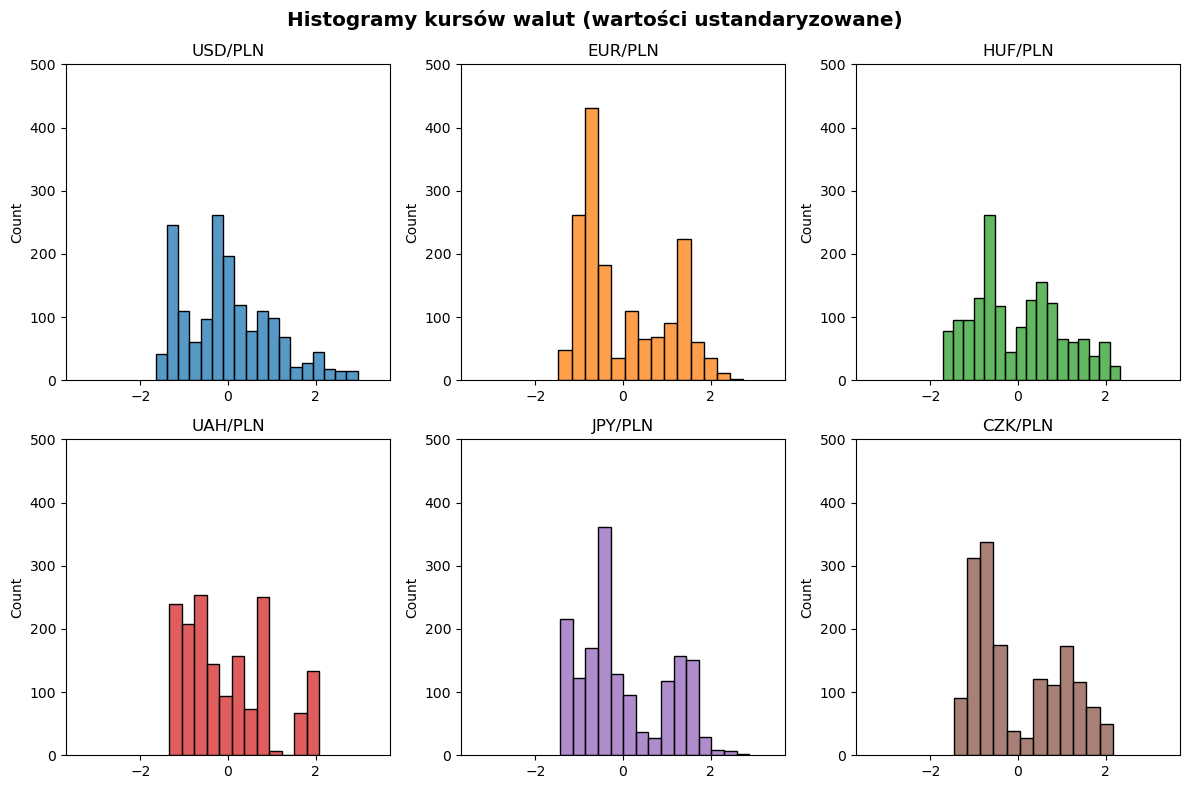

In [15]:
# histogramy po standaryzacji

fig, axs = plt.subplots(2, 3, figsize = (12,8), facecolor = 'white', tight_layout = True)

colors = ['C0', "C1", "C2", 'C3', 'C4', 'C5']

fig.suptitle("Histogramy kursów walut (wartości ustandaryzowane)", fontsize = "x-large", fontweight = "bold")

for ax, col, code, code_upp in zip(axs.flatten(), colors, codes, codes_upp):
    to_add = r"/PLN"
    sns.histplot(df_scaled[code], ax = ax, color = col)
    ax.set_xlabel(None)
    ax.set_title(code_upp + to_add)
    ax.set_ylim(0, 500)
    ax.set_xlim(-3.7, 3.7)

## Na ustandaryzowanej ramce danych - model ML

### <b>Inżynieria cech</b>

In [16]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

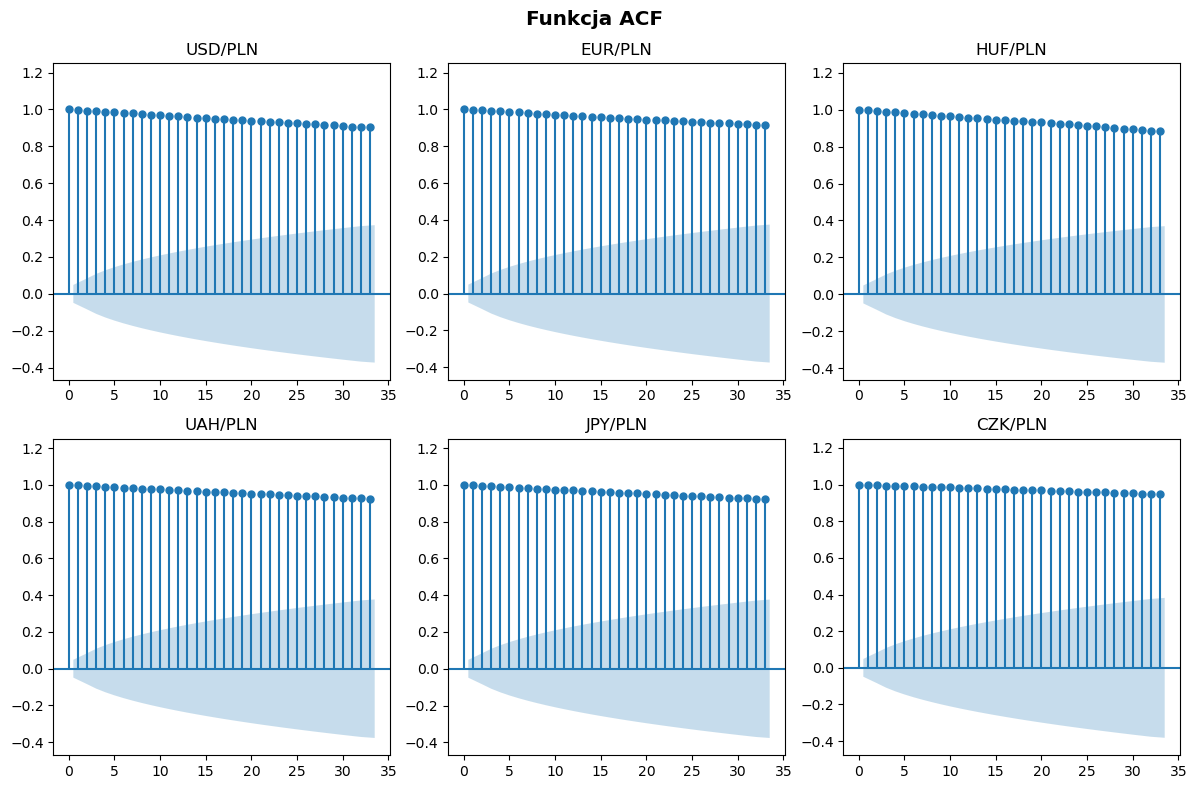

In [17]:
fig, axs = plt.subplots(2, 3, figsize = (12,8), facecolor = 'white', tight_layout = True)

colors = ['C0', "C1", "C2", 'C3', 'C4', 'C5']

fig.suptitle("Funkcja ACF", fontsize = "x-large", fontweight = "bold")

for ax, col, code, code_upp in zip(axs.flatten(), colors, codes, codes_upp):
    to_add = r"/PLN"
    plot_acf(df_scaled[code], ax = ax, auto_ylims = True, title = code_upp + to_add)

plt.show()

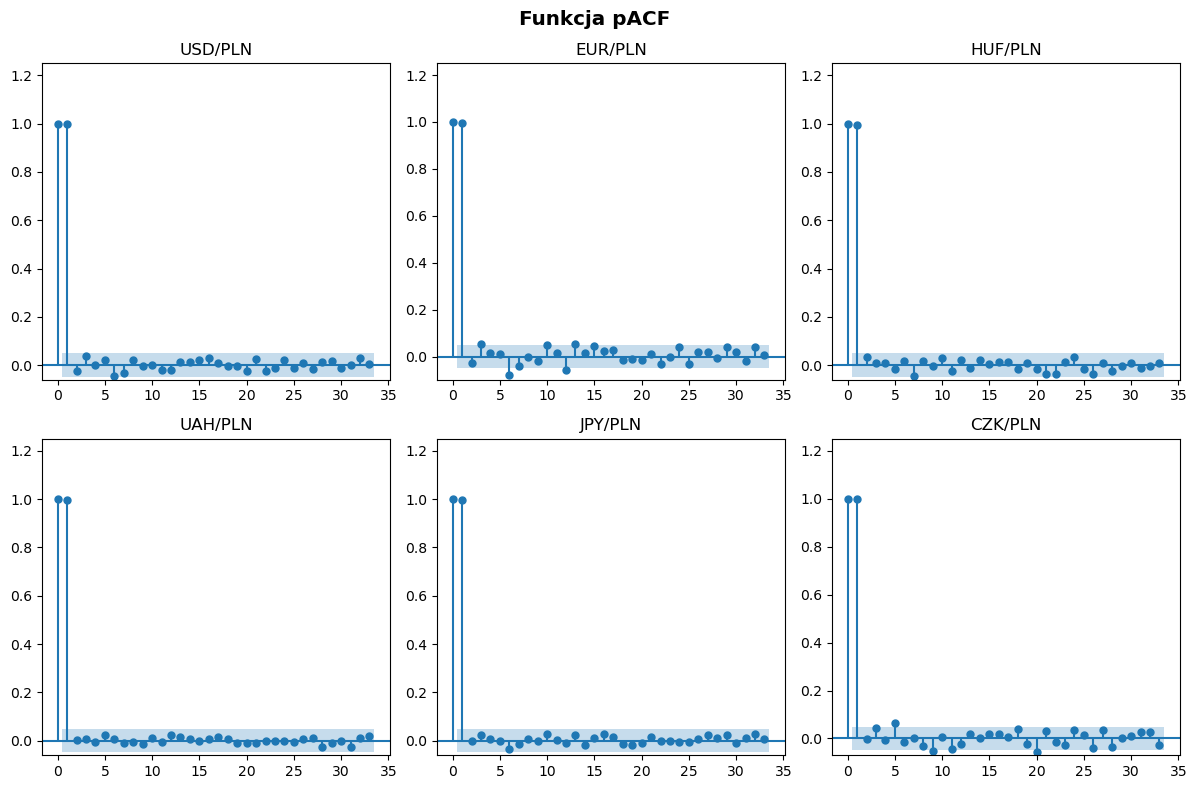

In [18]:
fig, axs = plt.subplots(2, 3, figsize = (12,8), facecolor = 'white', tight_layout = True)

colors = ['C0', "C1", "C2", 'C3', 'C4', 'C5']

fig.suptitle("Funkcja pACF", fontsize = "x-large", fontweight = "bold")

for ax, col, code, code_upp in zip(axs.flatten(), colors, codes, codes_upp):
    to_add = r"/PLN"
    plot_pacf(df_scaled[code], ax = ax, auto_ylims = True, title = code_upp + to_add)

plt.show()

In [19]:
# STL - dekompozycja szeregu czasowego
from statsmodels.tsa.seasonal import STL
# funkcja do rysowania wykresów
def plot_stl_res(stl_decomposed, name, color):
    y = stl_decomposed.observed
    trend = stl_decomposed.trend
    seasonal = stl_decomposed.seasonal
    resid = stl_decomposed.resid
    #fig, axs = plt.subplots(4, 1, figsize = (12,8), facecolor = 'white', tight_layout = True)
    fig, axs = plt.subplot_mosaic([['org', 'org', 'org'],
    ['trend', 'seasonal', 'resid']], tight_layout = True, figsize = (10,7))
    fig.suptitle(f"Dekompozycja szeregu czasowego {name}", fontsize = "x-large", fontweight = "bold")
    for _, ax in axs.items():
        ax.grid(visible = True)
        ax.tick_params('x', rotation = 45)
        sns.lineplot(y, ax = axs['org'], legend = False, color = color)
        axs['org'].set_title("Oryginalny szereg")
        sns.lineplot(trend, ax = axs['trend'], color = color)
        axs['trend'].set_title("Trend")
        sns.lineplot(seasonal, ax = axs['seasonal'], color = color)
        axs['seasonal'].set_title("Sezonowość")
        sns.lineplot(resid, ax = axs['resid'], color = color)
        axs['resid'].set_title("Rezydua")


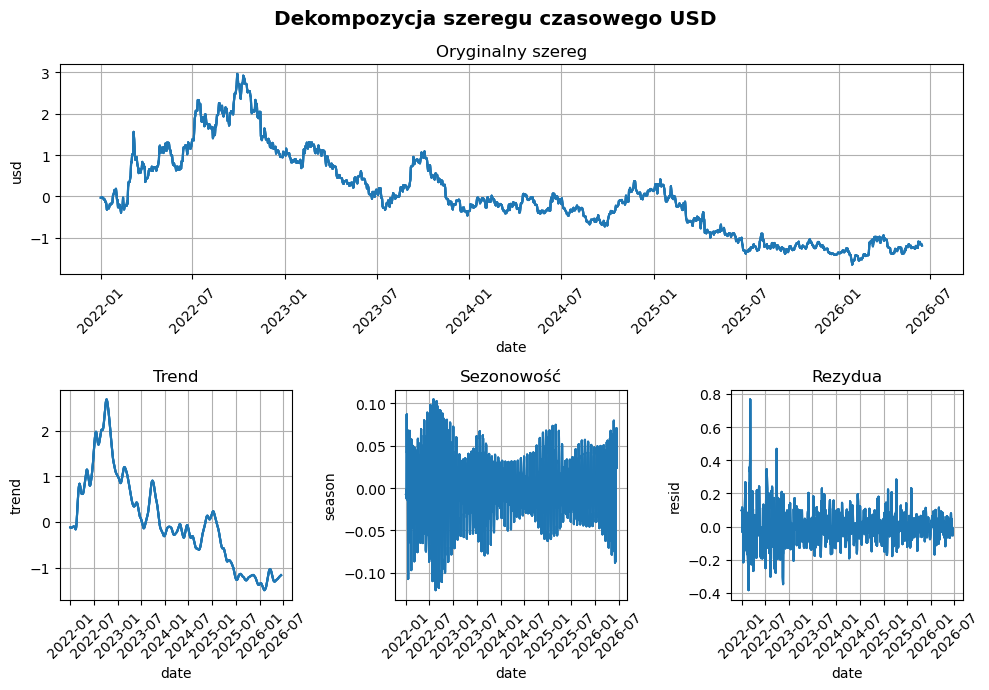

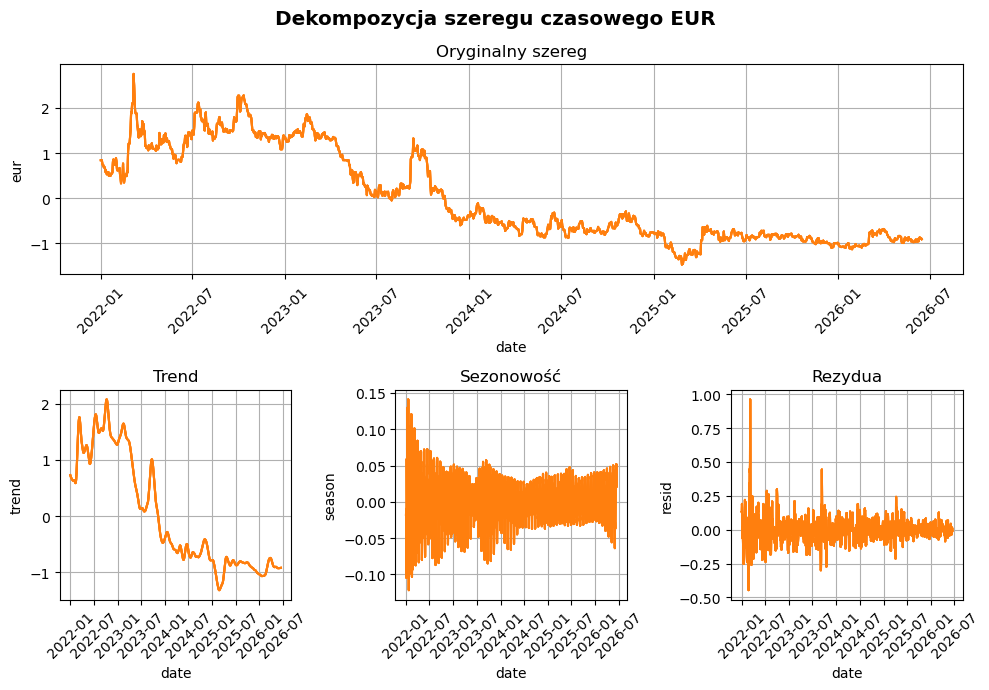

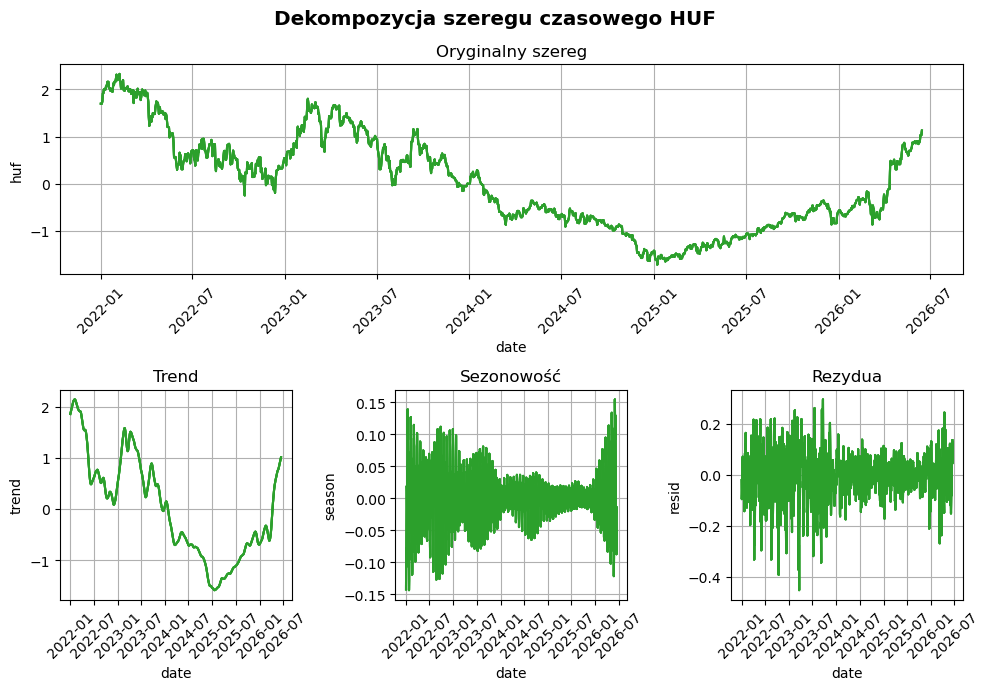

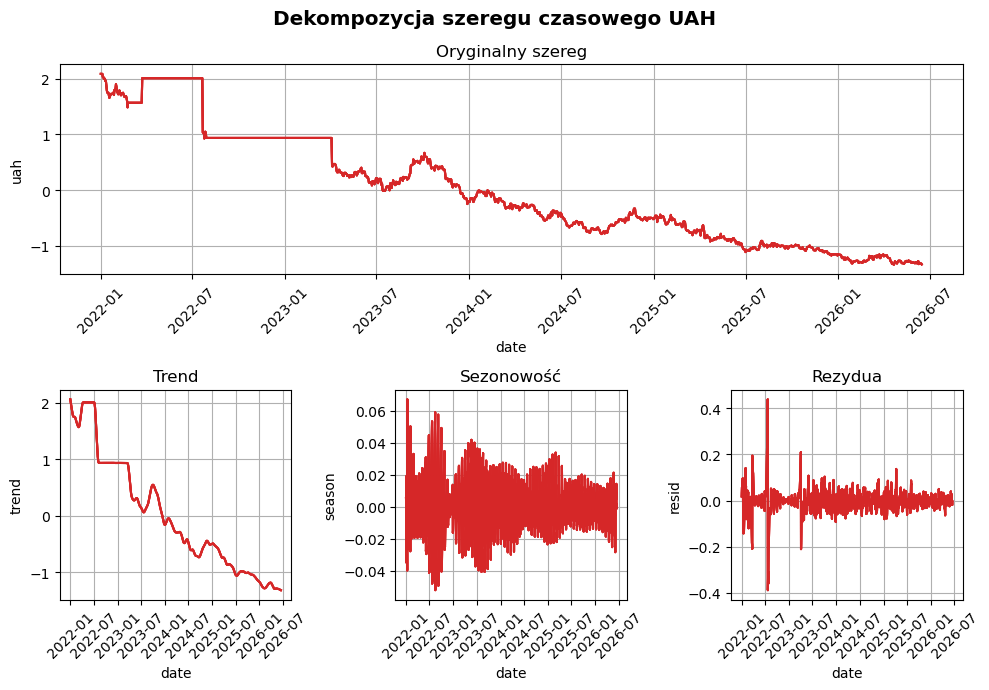

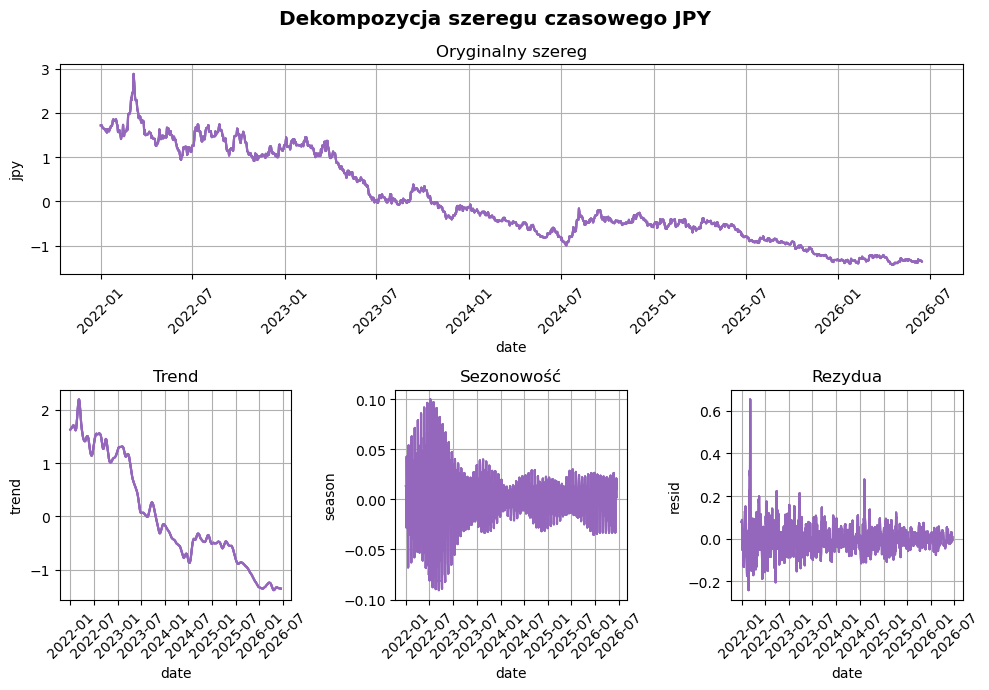

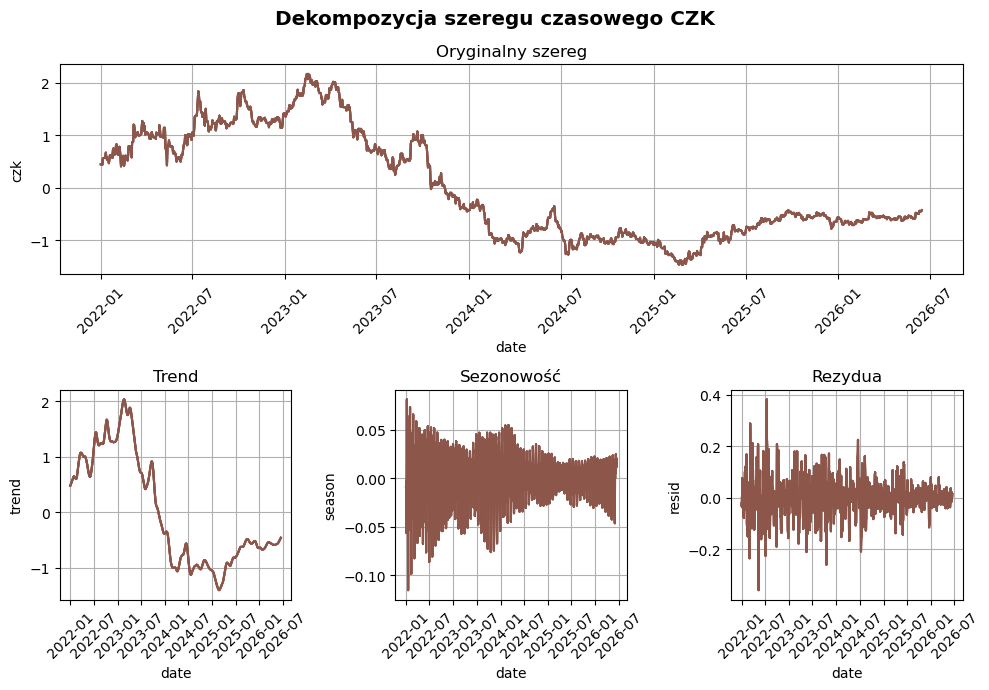

In [20]:
# wizualizacja dekompozycji i dodanie do dataframe
for i, code in enumerate(codes_upp):
    ts = df_scaled.iloc[:,i]
    name = df_scaled.columns[i]
    stl_res = STL(ts, period = 24, seasonal = 15).fit()

    df_scaled[f"{code.lower()}_trend"] = stl_res.trend
    df_scaled[f"{code.lower()}_seasonal"] = stl_res.seasonal
    df_scaled[f"{code.lower()}_resid"] = stl_res.resid
    
    plot_stl_res(stl_res, code, colors[i])

In [21]:
df_scaled

,usd,eur,huf,uah,jpy,czk,usd_trend,usd_seasonal,usd_resid,eur_trend,...,huf_resid,uah_trend,uah_seasonal,uah_resid,jpy_trend,jpy_seasonal,jpy_resid,czk_trend,czk_seasonal,czk_resid
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.120957,-0.006900,0.096936,0.728522,...,-0.020342,2.062105,0.005420,0.017997,1.629099,0.013117,0.077031,0.478411,-0.009040,-0.022632
2022-01-02,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.123017,-0.006097,0.098192,0.720250,...,-0.095045,2.045535,0.002414,0.037573,1.631531,0.012721,0.074996,0.484988,-0.003345,-0.034904
2022-01-03,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.124715,-0.009443,0.103235,0.712453,...,-0.077083,2.029204,-0.001044,0.057363,1.634161,-0.003227,0.088313,0.491598,-0.048661,0.003802
2022-01-04,-0.017694,0.764153,1.746687,2.085522,1.679268,0.436651,-0.126038,-0.006159,0.114502,0.705148,...,-0.043017,2.013132,0.019164,0.053226,1.636990,-0.017434,0.059712,0.498247,-0.056345,-0.005251
2022-01-05,-0.039339,0.731105,1.916423,2.029088,1.661164,0.557709,-0.126980,-0.001944,0.089585,0.698338,...,0.059297,1.997338,-0.010287,0.042037,1.640014,-0.013799,0.034950,0.504945,-0.023698,0.076462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-1.096938,-0.866386,0.902555,-1.305678,-1.329772,-0.441022,-1.175824,0.067964,0.010922,-0.925270,...,0.024106,-1.311473,0.009381,-0.003586,-1.355422,0.019476,0.006173,-0.481370,0.019618,0.020730
2026-06-12,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110,-1.173081,0.030761,-0.009032,-0.924770,...,0.107503,-1.312732,0.004564,-0.007771,-1.355797,0.009935,0.003768,-0.476547,0.012218,0.013218
2026-06-13,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110,-1.170386,0.070567,-0.051533,-0.924263,...,0.130457,-1.314011,0.014319,-0.016248,-1.356151,0.021004,-0.006946,-0.471684,0.020557,0.000016


In [22]:
# na podstawie wykresów pacf dodaję przesunięcia 1,5,6,7

for code in codes:

    for lag in [1,5,6,7]:
        df_scaled[f"{code}_lag{lag}"] = df_scaled[code].shift(lag)

df_scaled = df_scaled.bfill()

df_scaled


,usd,eur,huf,uah,jpy,czk,usd_trend,usd_seasonal,usd_resid,eur_trend,...,uah_lag6,uah_lag7,jpy_lag1,jpy_lag5,jpy_lag6,jpy_lag7,czk_lag1,czk_lag5,czk_lag6,czk_lag7
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.120957,-0.006900,0.096936,0.728522,...,2.085522,2.085522,1.719248,1.719248,1.719248,1.719248,0.446739,0.446739,0.446739,0.446739
2022-01-02,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.123017,-0.006097,0.098192,0.720250,...,2.085522,2.085522,1.719248,1.719248,1.719248,1.719248,0.446739,0.446739,0.446739,0.446739
2022-01-03,-0.030922,0.841435,1.696676,2.085522,1.719248,0.446739,-0.124715,-0.009443,0.103235,0.712453,...,2.085522,2.085522,1.719248,1.719248,1.719248,1.719248,0.446739,0.446739,0.446739,0.446739
2022-01-04,-0.017694,0.764153,1.746687,2.085522,1.679268,0.436651,-0.126038,-0.006159,0.114502,0.705148,...,2.085522,2.085522,1.719248,1.719248,1.719248,1.719248,0.446739,0.446739,0.446739,0.446739
2022-01-05,-0.039339,0.731105,1.916423,2.029088,1.661164,0.557709,-0.126980,-0.001944,0.089585,0.698338,...,2.085522,2.085522,1.679268,1.719248,1.719248,1.719248,0.436651,0.446739,0.446739,0.446739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-1.096938,-0.866386,0.902555,-1.305678,-1.329772,-0.441022,-1.175824,0.067964,0.010922,-0.925270,...,-1.310809,-1.290287,-1.342847,-1.385090,-1.385090,-1.352905,-0.451110,-0.501551,-0.501551,-0.481375
2026-06-12,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110,-1.173081,0.030761,-0.009032,-0.924770,...,-1.310809,-1.310809,-1.329772,-1.385090,-1.385090,-1.385090,-0.441022,-0.501551,-0.501551,-0.501551
2026-06-13,-1.151351,-0.889774,1.028341,-1.315939,-1.342093,-0.451110,-1.170386,0.070567,-0.051533,-0.924263,...,-1.310809,-1.310809,-1.342093,-1.308651,-1.385090,-1.385090,-0.451110,-0.491463,-0.501551,-0.501551


In [23]:
# okna czasowe - tygodniowe i miesięczne - średnia, mediana i odch. std rolling window
for code in codes:

    # rolling window
    rolling_mean_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").mean().bfill()
    rolling_median_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").median().bfill()
    rolling_std_week = df_scaled[code].rolling(7, min_periods = 1, closed = "left").std().bfill()

    rolling_mean_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").mean().bfill()
    rolling_median_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").median().bfill()
    rolling_std_month = df_scaled[code].rolling(30, min_periods = 1, closed = "left").std().bfill()

    # expanding window
    expanding_mean = df_scaled[code].expanding().mean()
    expanding_median = df_scaled[code].expanding().median()
    expanding_std = df_scaled[code].expanding().std()

    # dodanie do df
    df_scaled[f"{code}_mean_week"] = rolling_mean_week
    df_scaled[f"{code}_median_week"] = rolling_median_week
    df_scaled[f"{code}_std_week"] = rolling_std_week

    df_scaled[f"{code}_mean_month"] = rolling_mean_month
    df_scaled[f"{code}_median_month"] = rolling_median_month
    df_scaled[f"{code}_std_month"] = rolling_std_month

    df_scaled[f"{code}_exp_mean"] = expanding_mean
    df_scaled[f"{code}_exp_median"] = expanding_median
    df_scaled[f"{code}_exp_std"] = expanding_std

df_scaled = df_scaled.bfill()

In [24]:
# cechy oparte na czasie
df_scaled['month'] = df.index.month.astype("category")
df_scaled['day'] = df.index.day.astype("category")
df_scaled['quarter'] = df.index.quarter.astype("category")

df_scaled['month'] = df_scaled['month'].astype("category")
df_scaled['day'] = df_scaled['day'].astype("category")
df_scaled['quarter'] = df_scaled['quarter'].astype("category")

In [27]:
usd_df = get_features(df_scaled, "usd")
eur_df = get_features(df_scaled, "eur")
huf_df = get_features(df_scaled, "huf")
uah__df = get_features(df_scaled, "uah")
jpy_df = get_features(df_scaled, "jpy")
czk_df = get_features(df_scaled, "czk")

In [153]:
df = get_data_from_db()
df_to_ml = prepare_data(df)

for x in df_to_ml:
    if ('month' in x) or ('day' in x) or ('quarter' in x):
        print(x)

Polaczono!
usd_mean_month
usd_median_month
usd_std_month
eur_mean_month
eur_median_month
eur_std_month
huf_mean_month
huf_median_month
huf_std_month
uah_mean_month
uah_median_month
uah_std_month
jpy_mean_month
jpy_median_month
jpy_std_month
czk_mean_month
czk_median_month
czk_std_month
month_2
month_3
month_4
month_5
month_6
month_7
month_8
month_9
month_10
month_11
month_12
day_2
day_3
day_4
day_5
day_6
day_7
day_8
day_9
day_10
day_11
day_12
day_13
day_14
day_15
day_16
day_17
day_18
day_19
day_20
day_21
day_22
day_23
day_24
day_25
day_26
day_27
day_28
day_29
day_30
day_31
quarter_2
quarter_3
quarter_4
weekday_1
weekday_2
weekday_3
weekday_4
weekday_5
weekday_6


In [166]:
df = get_data_from_db()
df_to_ml = prepare_data(df)

Polaczono!


In [171]:
def get_features(df, code):
    
    cols = df.columns.tolist()
    datetime_cols = cols[-50:]
    code = code.lower()

    cols = [*filter(lambda x: code in x, cols)]

    return df[cols + datetime_cols]

In [175]:
get_features(df_to_ml, "usd").iloc[:,-51:]

,usd_exp_std,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,day_31,quarter_2,quarter_3,quarter_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2022-01-02,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2022-01-03,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-04,0.006614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-01-05,0.007765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,0.999879,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2026-06-12,0.999981,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2026-06-13,1.000083,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [169]:
get_features(df_to_ml, "usd")

,usd,usd_trend,usd_seasonal,usd_resid,usd_lag1,usd_lag5,usd_lag6,usd_lag7,usd_mean_week,usd_median_week,usd_std_week,usd_mean_month,usd_median_month,usd_std_month,usd_exp_mean,usd_exp_median,usd_exp_std
date,,,,,,,,,,,,,,,,,
2022-01-01,-0.030922,-0.120957,-0.006900,0.096936,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,0.000000,-0.030922,-0.030922,0.000000,-3.092188e-02,-0.030922,0.000000
2022-01-02,-0.030922,-0.123017,-0.006097,0.098192,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,0.000000,-0.030922,-0.030922,0.000000,-3.092188e-02,-0.030922,0.000000
2022-01-03,-0.030922,-0.124715,-0.009443,0.103235,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,0.000000,-0.030922,-0.030922,0.000000,-3.092188e-02,-0.030922,0.000000
2022-01-04,-0.017694,-0.126038,-0.006159,0.114502,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,0.000000,-0.030922,-0.030922,0.000000,-2.761501e-02,-0.030922,0.006614
2022-01-05,-0.039339,-0.126980,-0.001944,0.089585,-0.017694,-0.030922,-0.030922,-0.030922,-0.027615,-0.030922,0.006614,-0.027615,-0.030922,0.006614,-2.995988e-02,-0.030922,0.007765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-1.096938,-1.175824,0.067964,0.010922,-1.130308,-1.243042,-1.243042,-1.194641,-1.186310,-1.194641,0.061504,-1.217920,-1.223501,0.046544,2.857778e-03,-0.110588,0.999879
2026-06-12,-1.151351,-1.173081,0.030761,-0.009032,-1.096938,-1.243042,-1.243042,-1.243042,-1.172352,-1.159168,0.069822,-1.210795,-1.221096,0.048185,2.147058e-03,-0.112091,0.999981
2026-06-13,-1.151351,-1.170386,0.070567,-0.051533,-1.151351,-1.090926,-1.243042,-1.243042,-1.159254,-1.151351,0.062574,-1.207178,-1.211777,0.048447,1.437213e-03,-0.113594,1.000083


In [139]:
def make_df_dict(df_scaled):
    df_dict = {}
    for code in codes:
        temp = get_features(df_scaled, code)
        df_dict[code] = temp

    return df_dict

In [140]:
make_df_dict(df)['usd']

,usd,usd_trend,usd_seasonal,usd_resid,usd_lag1,usd_lag5,usd_lag6,usd_lag7,usd_mean_week,usd_median_week,...,day_31,quarter_2,quarter_3,quarter_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,-0.030922,-0.120957,-0.006900,0.096936,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2022-01-02,-0.030922,-0.123017,-0.006097,0.098192,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2022-01-03,-0.030922,-0.124715,-0.009443,0.103235,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-04,-0.017694,-0.126038,-0.006159,0.114502,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,-0.030922,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-01-05,-0.039339,-0.126980,-0.001944,0.089585,-0.017694,-0.030922,-0.030922,-0.030922,-0.027615,-0.030922,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-1.096938,-1.175824,0.067964,0.010922,-1.130308,-1.243042,-1.243042,-1.194641,-1.186310,-1.194641,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2026-06-12,-1.151351,-1.173081,0.030761,-0.009032,-1.096938,-1.243042,-1.243042,-1.243042,-1.172352,-1.159168,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2026-06-13,-1.151351,-1.170386,0.070567,-0.051533,-1.151351,-1.090926,-1.243042,-1.243042,-1.159254,-1.151351,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### <b>Model XGBoost</b>

In [28]:
from xgboost import XGBRegressor

In [29]:
# tworzymy osobny model dla każdej waluty
models_dict = {}
for code in codes:
    models_dict[code] = None

In [30]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV, train_test_split



In [26]:
def ts_train_test_split(X, y, test_size):
    test_size = int(len(df) * test_size)
    X_train = X.iloc[:-test_size]
    X_test = X.iloc[-test_size:]
    y_train = y.iloc[:-test_size]
    y_test = y.iloc[-test_size:]

    return X_train, X_test, y_train, y_test

In [27]:
test_size = 2

In [ ]:
tscv = TimeSeriesSplit(n_splits = 6)

param_grid = {'max_depth' : [6,9,12],
'n_estimators' : [100, 300, 500],
'eta' : [0.1, 0.3]}

best_params_dict = {}

for code in codes:

    curr_df = df_dict[code]
    X = curr_df.iloc[:,1:]
    y = curr_df.iloc[:,[0]]

    X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)
    
    print(f"Szukanie parametrów dla modelu dla {code.upper()}")
    
    model = XGBRegressor(enable_categorical = True)

    gs_cv = GridSearchCV(model, param_grid, cv = tscv)
    gs_cv.fit(X_train, y_train)
    
    best_params_dict[code] = gs_cv.best_params_
    

In [ ]:
len(json.dumps(best_params_dict))

In [28]:
def grid_search_best_params(df_dict):
    tscv = TimeSeriesSplit(n_splits = 6)
    
    param_grid = {'max_depth' : [6,9,12],
    'n_estimators' : [100, 300, 500],
    'eta' : [0.1, 0.3]}
    
    best_params_dict = {}
    
    for code in codes:
    
        curr_df = df_dict[code]
        X = curr_df.iloc[:,1:]
        y = curr_df.iloc[:,[0]]
    
        X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)
        
        print(f"Szukanie parametrów dla modelu dla {code.upper()}")
        
        model = XGBRegressor(enable_categorical = True)
    
        gs_cv = GridSearchCV(model, param_grid, cv = tscv)
        gs_cv.fit(X_train, y_train)
        
        best_params_dict[code] = gs_cv.best_params_

    return best_params_dict

In [29]:
# mogę trenować mój model!
# jeszcze cross_val_score!

In [30]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [31]:
def ts_cross_val_score(df_dict, best_params_dict):

    cv_scores = {}

    for code in codes:

        curr_df = df_dict[code]
        X = curr_df.iloc[:,1:]
        y = curr_df.iloc[:,[0]]

        X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)
        
        model = xgb.XGBRegressor(random_state = 415151, enable_categorical = True, **best_params_dict[code])
        
        rmse = []
        r2 = []
        
        tscv = TimeSeriesSplit(n_splits = 6)
        for train_ix, test_ix in tscv.split(X_train):
            X_train_cv = X_train.iloc[train_ix]
            y_train_cv = y_train.iloc[train_ix]
            X_test_cv = X_train.iloc[test_ix]
            y_test_cv = y_train.iloc[test_ix]
            model.fit(X_train_cv, y_train_cv)
            y_pred_cv = model.predict(X_test_cv)
            
            rmse.append(root_mean_squared_error(y_test_cv, y_pred_cv))
            r2.append(r2_score(y_test_cv, y_pred_cv))

        cv_scores[code] = {'rmse' : rmse, 'r2' : r2}

    return cv_scores

In [32]:
def train_models(df_dict, best_params_dict, train_existing = False, curr_models_dict = None):

    models_dict = {}
    test_scores_dict = {}
    
    for code in codes:

        curr_df = df_dict[code]
        X = curr_df.iloc[:,1:]
        y = curr_df.iloc[:,[0]]

        X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)

        model = xgb.XGBRegressor(random_state = 415151, enable_categorical = True, **best_params_dict[code])

        if train_existing:
            curr_model = curr_models_dict[code]
            model.fit(X_train, y_train, xgb_model = curr_model.get_booster())
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        test_scores_dict[code] = {'rmse' : rmse, 'r2' : r2}

        models_dict[code] = model

    return models_dict, test_scores

In [33]:
# to teraz funkcja zbierająca to wszystko

In [34]:
# cały pipeline - przygotowanie danych, szukanie parametrów, kroswalidacja, trening, zapisanie modelu do pliku

In [35]:
import pickle

In [36]:
def get_ml_models_and_scores(df, curr_models_dict = None):

    # jeśli models_dict jest none, to model jedziemy od 0

    # przygotowanie danych
    df_to_ml = prepare_data(df)

    # słownik przechowujący dane dla różnych walut
    df_dict = make_df_dict(df_to_ml)
    
    # GridSearch - najlepsze parametry
    best_params_dict = grid_search_best_params(df_dict)

    # kroswalidacja z najlepszymi parametrami
    cv_scores = ts_cross_val_score(df_dict, best_params_dict)

    train_existing = True
    if curr_models_dict is None:
        train_existing = False
    
    # trenowanie modeli
    models_dict, test_scores_dict = train_models(df_dict, best_params_dict, train_existing, curr_models_dict)

    return models_dict, best_params_dict, cv_scores, test_scores_dict

In [84]:
from statsmodels.tsa.arima.model import ARIMA

In [60]:
def make_arima_forecasts(X, extra_dates):
    # arima i sarimax trenowane na 3 miesięcznych danych
    # przewidywania na 2 tygodnie
    
    # arima dla trendu, reszt, okien
    # sarimax dla sezonowosci

    arima_cols = [0, 2, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    sarimax_col = 1

    last_date = X.index[-1]

    X_for_training = X.iloc[-90:, arima_cols + [sarimax_col]]

    X_final = pd.DataFrame(index = extra_dates, columns = X.columns)
    
    for col in X_for_training.columns[:-1]:

        arima_model = ARIMA(X_for_training.loc[:,col], order = (2,2,1), enforce_stationarity = False).fit()
        forecasts = arima_model.get_forecast(steps = 14).predicted_mean

        X_final.loc[extra_dates, col] = forecasts.values

    
    sarimax_model = SARIMAX(X_for_training.iloc[:,-1], order = (1,1,0), seasonal_order = (0,1,0,30)).fit()
    sarimax_forecasts = sarimax_model.get_forecast(steps = len(extra_dates)).predicted_mean
   
    X_final.iloc[:, sarimax_col] = sarimax_forecasts.values
    
    return pd.concat((X, X_final))

In [200]:
test = make_arima_forecasts(X, extra_dates)

C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\AdamD

In [61]:
usd_df.columns

NameError: name 'usd_df' is not defined

In [216]:
y

,usd
2022-01-01,-0.030922
2022-01-02,-0.030922
2022-01-03,-0.030922
2022-01-04,-0.017694
2022-01-05,-0.039339
...,...
2026-06-25,NaN
2026-06-26,NaN
2026-06-27,NaN
2026-06-28,NaN


In [226]:
X.loc['2022-01-01',:]

usd_trend          -0.120957
usd_seasonal       -0.006900
usd_resid           0.096936
usd_lag1           -0.030922
usd_lag5           -0.030922
usd_lag6           -0.030922
usd_lag7           -0.030922
usd_mean_week      -0.030922
usd_median_week    -0.030922
usd_std_week        0.000000
usd_mean_month     -0.030922
usd_median_month   -0.030922
usd_std_month       0.000000
usd_exp_mean       -0.030922
usd_exp_median     -0.030922
usd_exp_std         0.000000
month               1.000000
day                 1.000000
quarter             1.000000
Name: 2022-01-01 00:00:00, dtype: float64

In [143]:
df = get_data_from_db()
df = prepare_data(df)
len(df.columns)
df_dict = make_df_dict(df)

Polaczono!


In [147]:
def predict_data(df_dict, models_dict, model_type = "xgboost"):

    # po jednej wartości - przewidywanie po jednej dacie naraz
    # ta wymodelowana wartość posłuży potem do modelowania kolejnych
    
    predictions_dict = {}
    dt1 = datetime.timedelta(days = 1)
    dt2 = datetime.timedelta(days = 16)
    
    for code in codes:

        curr_df = df_dict[code]
        model = models_dict[code]
        
        print(f"{code} : {len(curr_df.columns)}")

        last_date = curr_df.index[-1]
        extra_dates = pd.date_range(last_date + dt1, last_date + dt2)

        X = curr_df.iloc[:,1:-50]
        y = curr_df.iloc[:,[0]]

        y_temp = pd.DataFrame(columns = y.columns, index = extra_dates)
        y_temp = pd.concat((y, y_temp))
        
        # arima i sarimax dla trendu, sezonowości i zmiennych w oknach
        X = make_arima_forecasts(X, extra_dates)

        # wybór zmiennych, gdzie jest shift
        lag_cols = [3,4,5,6]

        # nany na końcu uzupełniamy tymi przesunięciami, a wcześniejsze - tym co było
        for lag_col, lag in zip(lag_cols, [1,5,6,7]):
            colname = X.columns[lag_col]
            #print(X.loc[extra_dates, colname])
            #print(y_temp.shift(lag).loc[extra_dates].values)
            X.loc[extra_dates, colname] = y_temp.shift(lag).loc[extra_dates].values.flatten()
            
        X.iloc[:8] = curr_df.iloc[:8, 1:]
        
        # cechy czasowe
        X['month'] = X.index.month.astype("category")
        X['day'] = X.index.day.astype("category")
        X['quarter'] = X.index.quarter.astype("category")
        X['weekday'] = X.index.dayofweek.astype("category")

        X = pd.get_dummies(X, columns = ['month', 'day', 'quarter', 'weekday'], drop_first= True).astype(float)
        
        # teraz przewidywać WIERSZ PO WIERSZU - DATA PO DACIE
        # po tym mogę użyć wartości przewidzianych i uzupełniać kolejne lagi i przewidywać kolejne wartości

        for col in X.columns:
            print(col)
        return
        
        for date_ in extra_dates:
            
            row = X.loc[[date_]]
            
            y_predicted_for_date = 0
            if model_type == 'xgboost':
                y_predicted_for_date = model.predict(row)
            elif model_type == "arima":
                print(row.columns[np.isnan(row.values).flatten()])
                y_predicted_for_date = model.get_forecast(exog = row, steps = 1).predicted_mean
                
                
            y_temp.loc[date_] = y_predicted_for_date.values[0]
            
            if date_ != extra_dates[-1]:
                
                for lag_col, lag in zip(lag_cols, [1,5,6,7]):
                    
                    colname = X.columns[lag_col]
                
                    X.loc[date_ + dt1, colname] = y_temp.shift(lag).loc[date_ + dt1].values[0]
                
        predictions_dict[code] = y_temp.loc[extra_dates]
        
        
    return predictions_dict

In [150]:
for col in df_dict['usd'].columns:
    print(col)

usd
usd_trend
usd_seasonal
usd_resid
usd_lag1
usd_lag5
usd_lag6
usd_lag7
usd_mean_week
usd_median_week
usd_std_week
usd_mean_month
usd_median_month
usd_std_month
usd_exp_mean
usd_exp_median
usd_exp_std
eur_mean_month
eur_median_month
eur_std_month
huf_mean_month
huf_median_month
huf_std_month
uah_mean_month
uah_median_month
uah_std_month
jpy_mean_month
jpy_median_month
jpy_std_month
czk_mean_month
czk_median_month
czk_std_month
month_2
month_3
month_4
month_5
month_6
month_7
month_8
month_9
month_10
month_11
month_12
day_2
day_3
day_4
day_5
day_6
day_7
day_8
day_9
day_10
day_11
day_12
day_13
day_14
day_15
day_16
day_17
day_18
day_19
day_20
day_21
day_22
day_23
day_24
day_25
day_26
day_27
day_28
day_29
day_30
day_31
quarter_2
quarter_3
quarter_4
weekday_1
weekday_2
weekday_3
weekday_4
weekday_5
weekday_6


In [148]:
pred_dict = predict_data(df_dict, model_dict, "arima")

usd : 82
usd_trend
usd_seasonal
usd_resid
usd_lag1
usd_lag5
usd_lag6
usd_lag7
usd_mean_week
usd_median_week
usd_std_week
usd_mean_month
usd_median_month
usd_std_month
usd_exp_mean
usd_exp_median
usd_exp_std
eur_mean_month
eur_median_month
eur_std_month
huf_mean_month
huf_median_month
huf_std_month
uah_mean_month
uah_median_month
uah_std_month
jpy_mean_month
jpy_median_month
jpy_std_month
czk_mean_month
czk_median_month
czk_std_month
month_2
month_3
month_4
month_5
month_6
month_7
month_8
month_9
month_10
month_11
month_12
day_2
day_3
day_4
day_5
day_6
day_7
day_8
day_9
day_10
day_11
day_12
day_13
day_14
day_15
day_16
day_17
day_18
day_19
day_20
day_21
day_22
day_23
day_24
day_25
day_26
day_27
day_28
day_29
day_30
day_31
quarter_2
quarter_3
quarter_4
weekday_1
weekday_2
weekday_3
weekday_4
weekday_5
weekday_6


In [11]:
import matplotlib.pyplot as plt

In [66]:
def make_arima_forecasts(X, extra_dates):
    # arima i sarimax trenowane na 3 miesięcznych danych
    # przewidywania na 2 tygodnie
    
    # arima dla trendu, reszt, okien
    # sarimax dla sezonowosci

    arima_cols = [0, 2, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    sarimax_col = 1

    last_date = X.index[-1]

    X_for_training = X.iloc[-90:, arima_cols + [sarimax_col]]

    X_final = pd.DataFrame(index = extra_dates, columns = X.columns)
    
    for col in X_for_training.columns[:-1]:

        arima_model = ARIMA(X_for_training.loc[:,col], order = (2,2,1), enforce_stationarity = False).fit()
        forecasts = arima_model.get_forecast(steps = len(extra_dates)).predicted_mean

        X_final.loc[extra_dates, col] = forecasts.values


    sarimax_model = SARIMAX(X_for_training.iloc[:,-1], order = (1,1,0), seasonal_order = (0,1,0,30)).fit()
    sarimax_forecasts = sarimax_model.get_forecast(steps = len(extra_dates)).predicted_mean
   
    X_final.iloc[:, sarimax_col] = sarimax_forecasts.values
    
    return pd.concat((X, X_final))

In [106]:
pred_dict = predict_data(df_dict, model_dict, "arima")

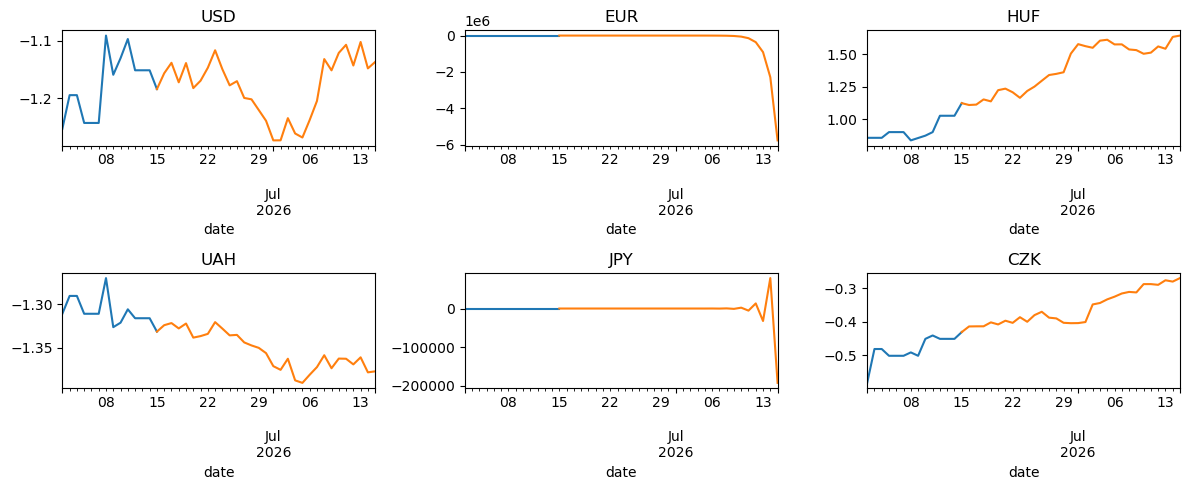

In [75]:
fig, axs = plt.subplots(2,3, figsize = (12,5), facecolor = 'white', tight_layout = True)


for ax, code in zip(axs.flatten(), codes):

    curr_df = df_dict[code]

    last_val = curr_df.iloc[-1,0]
    pred_vals = pred_dict[code]

    last_date = curr_df.index[-1]
    extra_dates = pd.date_range(last_date, last_date + timedelta(days = len(pred_vals)))
    
    # łączenie z ostatnią datą
    pred_vals = np.array([last_val, *pred_vals.values.flatten()])
    
    y_pred = pd.Series(pred_vals, index = extra_dates)
    
    curr_df[code].loc[curr_df.index > '2026-06-01'].plot(ax = ax)
    y_pred.loc[y_pred.index > '2026-06-01'].plot(ax = ax)

    ax.set_title(f"{code.upper()}")

In [126]:
(18000-75 * 6) / (75*6)

39.0

In [364]:
pred_dict['uah']

,uah
2026-06-16,-1.041922
2026-06-17,-1.045775
2026-06-18,-1.050810
2026-06-19,-1.050692
2026-06-20,-1.055190
2026-06-21,-1.060985
2026-06-22,-1.056756
2026-06-23,-1.052077
2026-06-24,-1.054994
2026-06-25,-1.058045


In [365]:
df_dict['uah'].iloc[[-1]]

,uah,uah_trend,uah_seasonal,uah_resid,uah_lag1,uah_lag5,uah_lag6,uah_lag7,uah_mean_week,uah_median_week,uah_std_week,uah_mean_month,uah_median_month,uah_std_month,uah_exp_mean,uah_exp_median,uah_exp_std,month,day,quarter
date,,,,,,,,,,,,,,,,,,,,
2026-06-15,-1.33133,-1.316628,0.00152,-0.016222,-1.315939,-1.321069,-1.3262,-1.269765,-1.310076,-1.315939,0.018834,-1.296101,-1.300548,0.017553,1.914742e-16,-0.269335,1.000307,6,15,2


In [389]:
model = model_dict['czk']

df = df_dict['czk']

In [390]:
X = df.iloc[:, 1:]
y = df.iloc[:,[0]]

X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)

In [391]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eta=0.3, eval_metric=None,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [392]:
y_pred = model.predict(X_test)

In [393]:
yy = pd.Series(y_pred, index = y_test.index)

<Axes: xlabel='date'>

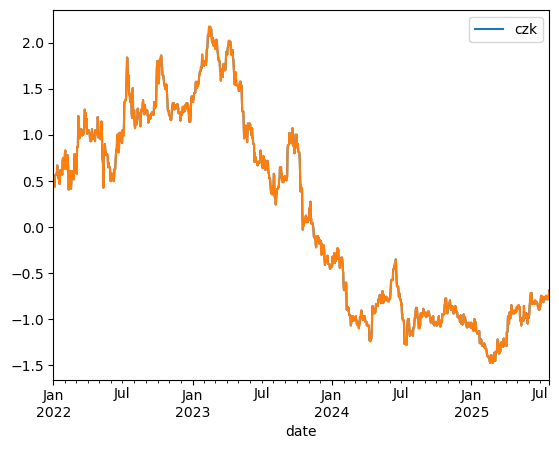

In [404]:
fig, ax = plt.subplots(1,1)

y_train.plot(ax = ax)
yyy.plot(ax = ax)


In [402]:
r2_score(y_test, yy)

0.40762096643447876

In [403]:
yyy = pd.Series(model.predict(X_train), index = y_train.index)

In [395]:
df

,czk,czk_trend,czk_seasonal,czk_resid,czk_lag1,czk_lag5,czk_lag6,czk_lag7,czk_mean_week,czk_median_week,czk_std_week,czk_mean_month,czk_median_month,czk_std_month,czk_exp_mean,czk_exp_median,czk_exp_std,month,day,quarter
date,,,,,,,,,,,,,,,,,,,,
2022-01-01,0.446739,0.478411,-0.009040,-0.022632,0.446739,0.446739,0.446739,0.446739,0.446739,0.446739,0.000000,0.446739,0.446739,0.000000,4.467391e-01,0.446739,0.000000,1,1,1
2022-01-02,0.446739,0.484988,-0.003345,-0.034904,0.446739,0.446739,0.446739,0.446739,0.446739,0.446739,0.000000,0.446739,0.446739,0.000000,4.467391e-01,0.446739,0.000000,1,2,1
2022-01-03,0.446739,0.491598,-0.048661,0.003802,0.446739,0.446739,0.446739,0.446739,0.446739,0.446739,0.000000,0.446739,0.446739,0.000000,4.467391e-01,0.446739,0.000000,1,3,1
2022-01-04,0.436651,0.498247,-0.056345,-0.005251,0.446739,0.446739,0.446739,0.446739,0.446739,0.446739,0.000000,0.446739,0.446739,0.000000,4.442171e-01,0.446739,0.005044,1,4,1
2022-01-05,0.557709,0.504945,-0.023698,0.076462,0.436651,0.446739,0.446739,0.446739,0.444217,0.446739,0.005044,0.444217,0.446739,0.005044,4.669155e-01,0.446739,0.050943,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-0.441022,-0.481370,0.019618,0.020730,-0.451110,-0.501551,-0.501551,-0.481375,-0.490022,-0.501551,0.018809,-0.546612,-0.562081,0.040068,1.099363e-03,-0.501551,1.001294,6,11,2
2026-06-12,-0.451110,-0.476547,0.012218,0.013218,-0.441022,-0.501551,-0.501551,-0.501551,-0.484257,-0.501551,0.026509,-0.542577,-0.557037,0.044326,8.209082e-04,-0.501551,1.001049,6,12,2
2026-06-13,-0.451110,-0.471684,0.020557,0.000016,-0.451110,-0.491463,-0.501551,-0.501551,-0.477052,-0.491463,0.027846,-0.539214,-0.551992,0.047313,5.427966e-04,-0.501551,1.000803,6,13,2


In [399]:
pred_dict = predict_data(df_dict, model_dict)

<Axes: >

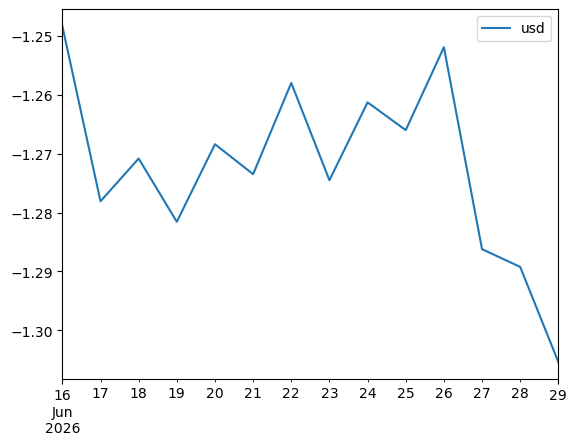

In [400]:
pred_dict['usd'].plot()

In [50]:
model_dict = model_dict_from_pickle()

In [59]:
predict_data(df_dict, model_dict, "arima")

C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


UnboundLocalError: cannot access local variable 'y_predicted_for_date' where it is not associated with a value

In [53]:
df = df_dict['uah']

X = df.iloc[:,1:]
y = df.iloc[:,[0]]

X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)

In [54]:
import matplotlib.pyplot as plt

In [ ]:
fig, ax = plt.subplots()

y_test.plot(ax = ax)
y_pred.plot(ax = ax)

In [78]:
import xgboost as xgb

In [108]:
model2 = xgb.XGBRegressor(enable_categorical = True, reg_lambda = 15, eta = 0.1, max_depth = 3, n_estimators = 50,
                         min_child_weight = 7, subsample = 0.5, **{'colsample_bytree':0.5, 'colsample_bylevel':0.5, 'colsample_bynode':0.5})

In [109]:
model2.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.5, colsample_bynode=0.5, colsample_bytree=0.5,
             device=None, early_stopping_rounds=None, enable_categorical=True,
             eta=0.1, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=7, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, ...)

Text(0.5, 1.0, 'Zbiór testowy')

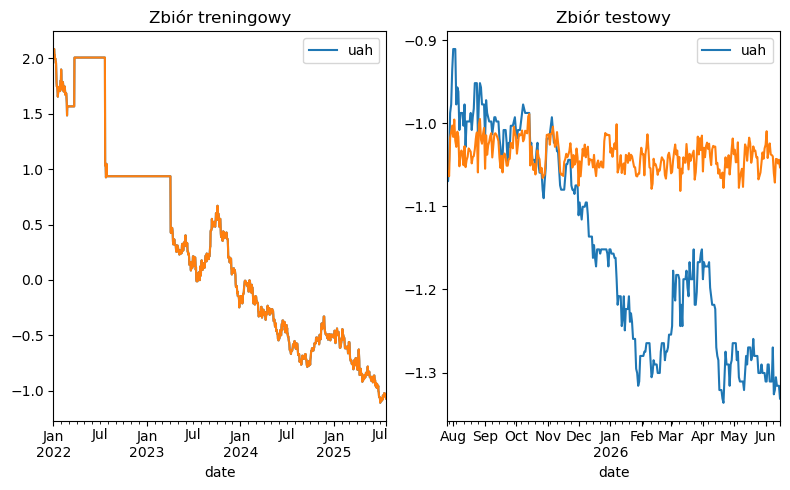

In [110]:
fig, axs = plt.subplots(2, 3, figsize = (10,7), tight_layout = True)

y_pred_train = pd.Series(model.predict(X_train), index = y_train.index)

y_train.plot(ax = axs[0])
y_pred_train.plot(ax = axs[0])

y_pred_test = pd.Series(model.predict(X_test), index = y_test.index)

y_test.plot(ax = axs[1])
y_pred_test.plot(ax = axs[1])

axs[0].set_title("Zbiór treningowy")
axs[1].set_title("Zbiór testowy")

<Axes: xlabel='date'>

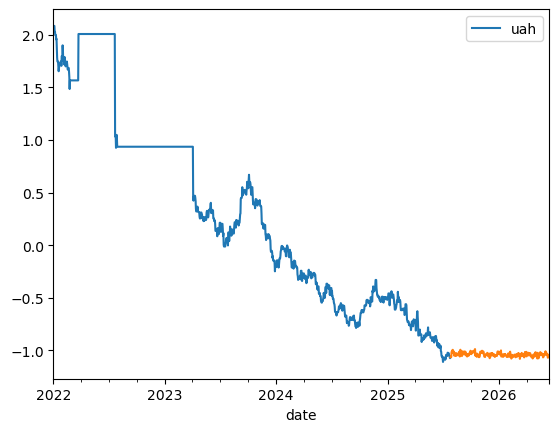

In [112]:
fig, ax = plt.subplots()

y_train.plot(ax = ax)
y_pred_test.plot(ax =ax)

In [82]:
arima_model = ARIMA(y_train, X_train, order = (2, 2, 1)).fit()

C:\Users\AdamD\anaconda3\envs\DataScience\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [113]:
from sklearn.ensemble import RandomForestRegressor

In [114]:
rf_reg = RandomForestRegressor(max_depth = 9, n_estimators = 300)

In [115]:
rf_reg.fit(X_train, y_train)
y_pred_rf = pd.Series(rf_reg.predict(X_test), index = y_test.index)

In [84]:
y_pred_arima = arima_model.get_forecast(exog = X_test, steps = len(y_test)).predicted_mean

<Axes: xlabel='date'>

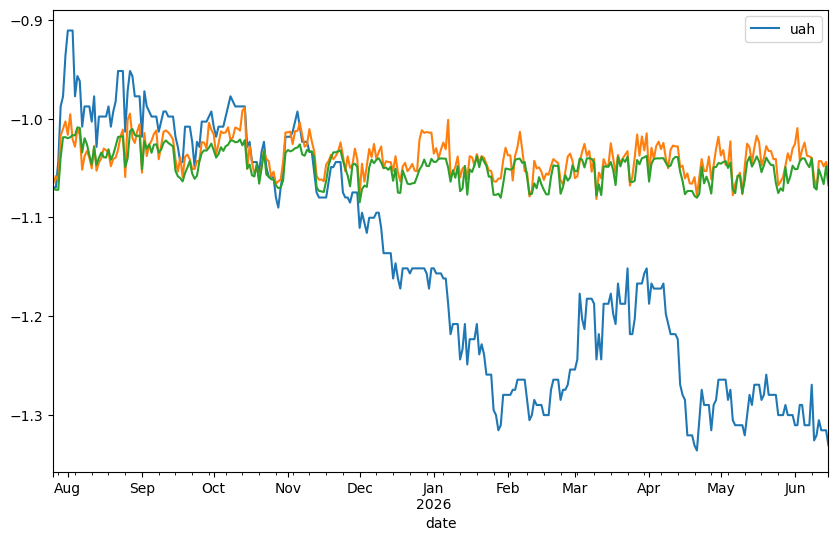

In [116]:
fig, ax = plt.subplots(1, 1, figsize = (10,6))

y_test.plot(ax = ax)
y_pred_test.plot(ax = ax)
y_pred_rf.plot(ax = ax)

In [87]:
r2_score(y_test, y_pred_arima)

0.9999915881789692

In [117]:
def evaluate_arima(X, y, order : tuple, seasonal_order : tuple):

    model = ARIMA(y, X, order = order, seasonal_order = seasonal_order).fit()

    y_pred = model.get_forecast(exog = X, steps = len(y))
    
    rmse = root_mean_squared_error(y, y_pred)

    return rmse

In [122]:
5*3*5

75

In [132]:
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=8, test_size=None)

In [133]:
def arima_grid_search(df_dict, cv):

    param_grid = {
        'p': [0,1,2,3,4],
        'd' : [0,1,2],
        'q' : [0,1,2,3,4],
        }
    
    best_params_dict = {}
    
    for code in codes:

        curr_df = df_dict[code]
        X = curr_df.iloc[:,1:]
        y = curr_df.iloc[:,[0]]

        p_vals = param_grid['p']
        d_vals = param_grid['d']
        q_vals = param_grid['q']
    
    
        rmse = 1e9
        r2 = -10

        best_params = {}
                
        for p in p_vals:
            for d in d_vals:
                for q in q_vals:

                    rmse_arr = []
                    r2_arr = []
                    
                    order = (p, d, q)
                    print(f"Sprawdzam {order}")
                    X_train, X_test, y_train, y_test = ts_train_test_split(X, y, 0.2)
                                    
                    for train_ix, test_ix in cv.split(X_train):
                        X_train_cv = X_train.iloc[train_ix]
                        y_train_cv = y_train.iloc[train_ix]
                        X_test_cv = X_train.iloc[test_ix]
                        y_test_cv = y_train.iloc[test_ix]

                        model = ARIMA(y_train_cv, X_train_cv, order = order).fit()
                                        
                        y_pred_cv = model.get_forecast(exog = X_test_cv, steps = len(y_test_cv)).predicted_mean
                            
                        rmse_arr.append(root_mean_squared_error(y_test_cv, y_pred_cv))
                        r2_arr.append(r2_score(y_test_cv, y_pred_cv))

                    rmse_cv = np.array(rmse_arr).mean()
                    r2_cv = np.array(r2_arr).mean()
                    
                    if rmse_cv < rmse and r2_cv > r2:
                        rmse = rmse_cv
                        r2 = r2_cv
                        best_params = {'order' : order}

        print("Spradzone!")

        best_params_dict[code] = best_params

    return best_params_dict
                                
    

In [134]:
tscv = TimeSeriesSplit(n_splits = 6)

In [137]:
arima_grid_search(df_dict, tscv)

Sprawdzam (0, 0, 0)
Sprawdzam (0, 0, 1)
Sprawdzam (0, 0, 2)
Sprawdzam (0, 0, 3)
Sprawdzam (0, 0, 4)
Sprawdzam (0, 1, 0)


KeyboardInterrupt: 

In [140]:
3*3*2*6*6

972